# Desafío - Redes neuronales (Parte I)

El objetivo es predecir si un cliente de telecomunicaciones renunciará (`Churn`) usando:

1. Preprocesamiento y análisis exploratorio.
2. Balanceo de clases con **SMOTE**.
3. Un modelo **RandomForest** para seleccionar las 7 variables más importantes.
4. Una red neuronal **feedforward** con Keras/TensorFlow, usando solo esas 7 variables.

La variable objetivo es:

- `0`: cliente no renuncia.
- `1`: cliente renuncia.

## 1. Importación de librerías

In [2]:
pip install tensorflow imbalanced-learn

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 2. Carga de datos

El archivo esperado es `Customer Churn.csv`.  
Si no está disponible directamente, el notebook intenta extraerlo desde el zip de apoyo.

In [4]:
csv_file = "Customer Churn.csv"
zip_file = "Apoyo Desafío - Redes neuronales (Parte I).zip"

if not os.path.exists(csv_file):
    if os.path.exists(zip_file):
        with zipfile.ZipFile(zip_file, "r") as zip_ref:
            zip_ref.extractall(".")
    else:
        raise FileNotFoundError("No se encontró Customer Churn.csv ni el archivo zip de apoyo.")

df = pd.read_csv(csv_file)
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [5]:
print("Dimensiones:", df.shape)
df.info()

Dimensiones: (3150, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtype

In [6]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Call Failure,3150.0,7.627937,7.263886,0.0,1.00000,6.00,12.00000,36.00
Complains,3150.0,0.076508,0.265851,0.0,0.00000,0.00,0.00000,1.00
Subscription Length,3150.0,32.541905,8.573482,3.0,30.00000,35.00,38.00000,47.00
Charge Amount,3150.0,0.942857,1.521072,0.0,0.00000,0.00,1.00000,10.00
Seconds of Use,3150.0,4472.459683,4197.908687,0.0,1391.25000,2990.00,6478.25000,17090.00
Frequency of use,3150.0,69.460635,57.413308,0.0,27.00000,54.00,95.00000,255.00
Frequency of SMS,3150.0,73.174921,112.237560,0.0,6.00000,21.00,87.00000,522.00
Distinct Called Numbers,3150.0,23.509841,17.217337,0.0,10.00000,21.00,34.00000,97.00
Age Group,3150.0,2.826032,0.892555,1.0,2.00000,3.00,3.00000,5.00
Tariff Plan,3150.0,1.077778,0.267864,1.0,1.00000,1.00,1.00000,2.00


## 3. Limpieza inicial

Se revisan nombres de columnas, valores ausentes y duplicados.  
La base viene sin valores nulos, pero se deja el chequeo porque es una buena práctica.

In [7]:
# Normalizar nombres de columnas para evitar problemas por dobles espacios.
df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)
df.columns

Index(['Call Failure', 'Complains', 'Subscription Length', 'Charge Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='object')

In [9]:
print("Valores ausentes por columna:")
print(df.isna().sum())

print("Filas duplicadas:", df.duplicated().sum())

Valores ausentes por columna:
Call Failure               0
Complains                  0
Subscription Length        0
Charge Amount              0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64
Filas duplicadas: 300


In [10]:
# Si existieran duplicados exactos, se eliminan.
df = df.drop_duplicates().reset_index(drop=True)
print("Dimensiones después de eliminar duplicados:", df.shape)

Dimensiones después de eliminar duplicados: (2850, 14)


## 4. Análisis de `Subscription Length` según `Churn`

Se analiza si la antigüedad de suscripción tiene relación visual con la renuncia del cliente.

In [11]:
resumen_subscription = df.groupby("Churn")["Subscription Length"].describe()
resumen_subscription

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,2404.0,32.595674,8.508031,3.0,29.0,35.0,38.0,47.0
1,446.0,31.683857,9.775965,3.0,31.0,35.0,37.0,45.0


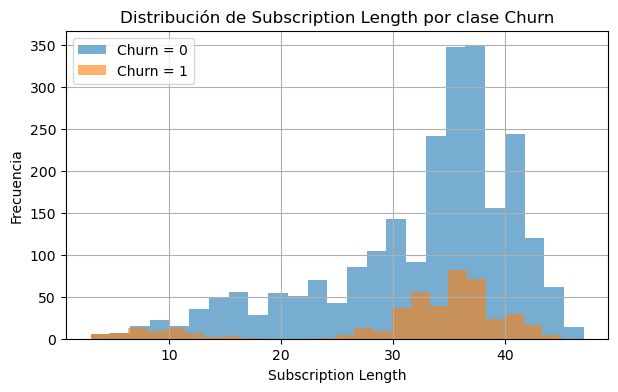

In [12]:
plt.figure(figsize=(7, 4))
for clase in sorted(df["Churn"].unique()):
    df.loc[df["Churn"] == clase, "Subscription Length"].hist(
        bins=25,
        alpha=0.6,
        label=f"Churn = {clase}"
    )

plt.title("Distribución de Subscription Length por clase Churn")
plt.xlabel("Subscription Length")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
df.boxplot(column="Subscription Length", by="Churn")
plt.title("Subscription Length según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Subscription Length")
plt.show()

### Comentario sobre `Subscription Length`

Al comparar `Subscription Length` por clase, se observa que los clientes que renuncian tienden a concentrarse en ciertos rangos de antigüedad.  
Esto sugiere que la variable puede aportar información al modelo, aunque por sí sola no basta para separar perfectamente ambas clases.


## 5. Separación de variables y estandarización

Se separa la variable objetivo `Churn` de las variables regresoras.  
Luego se estandarizan las variables para que todas queden en una escala comparable.

In [13]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X_scaled.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value
0,0.026969,-0.296287,0.636013,-0.628722,-0.039115,0.008975,-0.613961,-0.399660,0.184601,-0.295586,-0.561951,-0.121574,-0.539223
1,-1.065198,-0.296287,0.750672,-0.628722,-1.004112,-1.141022,-0.596110,-1.155874,-0.934786,-0.295586,1.779513,-0.685884,-0.833972
2,0.300011,-0.296287,0.521355,-0.628722,-0.495655,-0.182691,2.545548,0.007532,0.184601,-0.295586,-0.561951,-0.121574,2.063820
3,0.300011,-0.296287,0.636013,-0.628722,-0.080077,-0.078146,-0.649661,0.647405,-2.054174,-0.295586,-0.561951,-1.814504,-0.456828
4,-0.655636,-0.296287,0.636013,-0.628722,-0.509944,-0.217540,-0.640736,0.531064,-2.054174,-0.295586,-0.561951,-1.814504,-0.640000


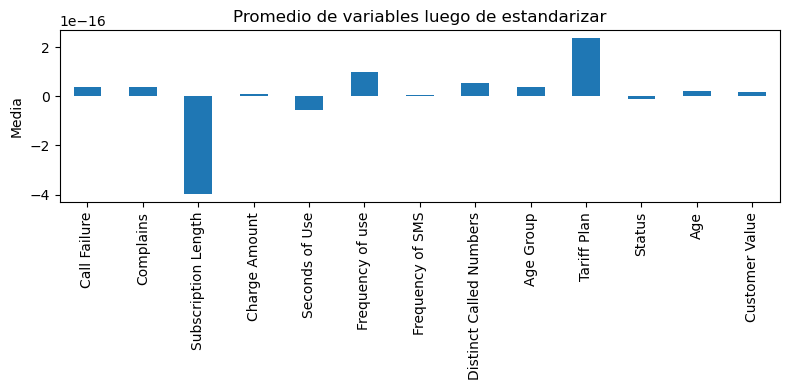

In [14]:
plt.figure(figsize=(8, 4))
X_scaled.mean().plot(kind="bar")
plt.title("Promedio de variables luego de estandarizar")
plt.ylabel("Media")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 6. Frecuencia de clases y balanceo con SMOTE

Primero se muestra el desbalance original.  
Luego se aplica **SMOTE**, que genera ejemplos sintéticos de la clase minoritaria para equilibrar la base.

Frecuencia original:
Churn
0    2404
1     446
Name: count, dtype: int64


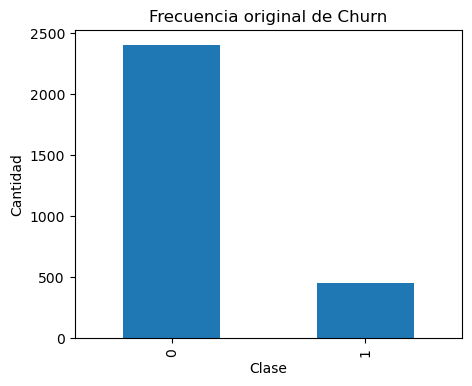

In [15]:
print("Frecuencia original:")
print(y.value_counts())

plt.figure(figsize=(5, 4))
y.value_counts().sort_index().plot(kind="bar")
plt.title("Frecuencia original de Churn")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

Frecuencia después de SMOTE:
Churn
0    2404
1    2404
Name: count, dtype: int64


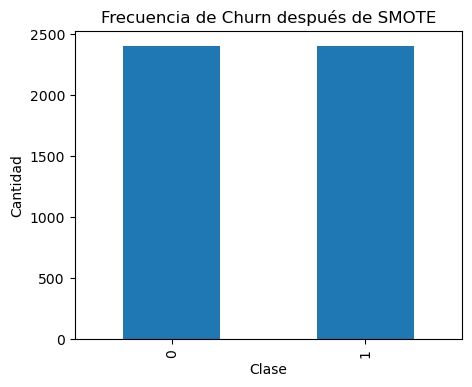

In [16]:
smote = SMOTE(random_state=RANDOM_STATE)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

print("Frecuencia después de SMOTE:")
print(pd.Series(y_balanced).value_counts())

plt.figure(figsize=(5, 4))
pd.Series(y_balanced).value_counts().sort_index().plot(kind="bar")
plt.title("Frecuencia de Churn después de SMOTE")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

**SMOTE** no duplica los registros de la clase minoritaria. Genera nuevas observaciones sintéticas interpolando entre ejemplos existentes y sus vecinos más cercanos, logrando equilibrar las clases sin perder la variabilidad de los datos

## 7. División en entrenamiento y test

Se divide la base balanceada en:

- 67% entrenamiento.
- 33% test.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.33,
    random_state=RANDOM_STATE,
    stratify=y_balanced
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Distribución y_train:")
print(pd.Series(y_train).value_counts(normalize=True))
print("Distribución y_test:")
print(pd.Series(y_test).value_counts(normalize=True))

Tamaño X_train: (3221, 13)
Tamaño X_test: (1587, 13)
Distribución y_train:
Churn
1    0.500155
0    0.499845
Name: proportion, dtype: float64
Distribución y_test:
Churn
0    0.500315
1    0.499685
Name: proportion, dtype: float64


## 8. Modelo RandomForest

Se entrena un `RandomForestClassifier` con hiperparámetros por defecto.  
Luego se revisa el F1-score para ambas clases y se extraen las 7 variables más importantes.

In [18]:
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf, digits=4))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0     0.9818    0.9521    0.9668       794
           1     0.9535    0.9823    0.9677       793

    accuracy                         0.9672      1587
   macro avg     0.9677    0.9672    0.9672      1587
weighted avg     0.9677    0.9672    0.9672      1587

Matriz de confusión:
[[756  38]
 [ 14 779]]


In [19]:
importancias_rf = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": rf_model.feature_importances_
}).sort_values("importancia", ascending=False)

top7_features = importancias_rf.head(7)["variable"].tolist()

print("Siete características más importantes:")
print(top7_features)

importancias_rf.head(7)

Siete características más importantes:
['Status', 'Complains', 'Seconds of Use', 'Frequency of use', 'Subscription Length', 'Customer Value', 'Distinct Called Numbers']


,variable,importancia
10,Status,0.160067
1,Complains,0.129803
4,Seconds of Use,0.121068
5,Frequency of use,0.115150
2,Subscription Length,0.108981
12,Customer Value,0.105066
7,Distinct Called Numbers,0.070814


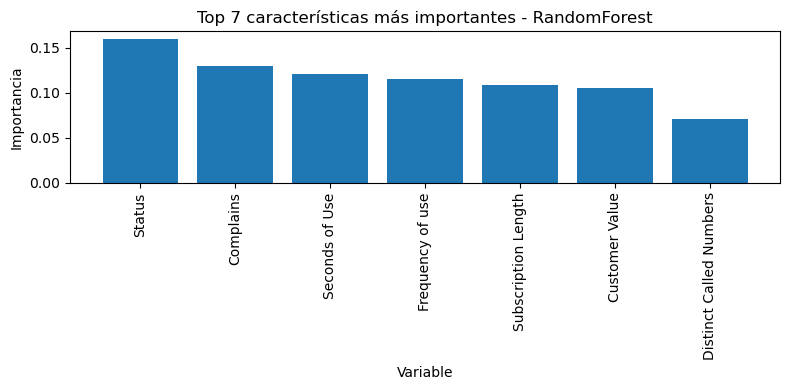

In [20]:
plt.figure(figsize=(8, 4))
plt.bar(importancias_rf.head(7)["variable"], importancias_rf.head(7)["importancia"])
plt.title("Top 7 características más importantes - RandomForest")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Comentario sobre RandomForest

RandomForest permite detectar qué variables aportan más a la clasificación.  
Estas 7 variables se usarán como entrada de la red neuronal para reducir ruido y trabajar con las señales más relevantes.

## 9. Preparación de datos para la red neuronal

Se filtran los conjuntos de entrenamiento y test usando solo las 7 variables seleccionadas por RandomForest.

In [22]:
X_train_nn = X_train[top7_features]
X_test_nn = X_test[top7_features]

print("Variables usadas en la red neuronal:")
print(X_train_nn.columns.tolist())
print("Tamaño X_train_nn:", X_train_nn.shape)
print("Tamaño X_test_nn:", X_test_nn.shape)

Variables usadas en la red neuronal:
['Status', 'Complains', 'Seconds of Use', 'Frequency of use', 'Subscription Length', 'Customer Value', 'Distinct Called Numbers']
Tamaño X_train_nn: (3221, 7)
Tamaño X_test_nn: (1587, 7)


## 10. Modelo de red neuronal feedforward

Se construye una red neuronal simple con:

- 1 capa oculta.
- Activación `relu` en la capa oculta.
- Activación `sigmoid` en la salida, porque el problema es binario.
- Optimizador `SGD`, es decir, Descenso del Gradiente Estocástico.
- Métrica principal: `AUC`.

Los hiperparámetros fueron ajustados manualmente buscando AUC mayor a 90%.

In [23]:
model = Sequential()
model.add(Dense(16, activation="relu", input_shape=(X_train_nn.shape[1],)))
model.add(Dense(1, activation="sigmoid"))

optimizer = SGD(learning_rate=0.05)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    X_train_nn,
    y_train,
    validation_split=0.2,
    epochs=120,
    batch_size=32,
    verbose=0
)

historial = pd.DataFrame(history.history)
historial.tail()

,accuracy,auc,loss,val_accuracy,val_auc,val_loss
115,0.915761,0.972237,0.208047,0.92093,0.975244,0.198518
116,0.915761,0.972291,0.207689,0.92093,0.975331,0.198239
117,0.916537,0.972367,0.207282,0.91938,0.975288,0.197991
118,0.916925,0.972468,0.206942,0.91938,0.975350,0.197779
119,0.918478,0.972570,0.206532,0.91938,0.975586,0.197531


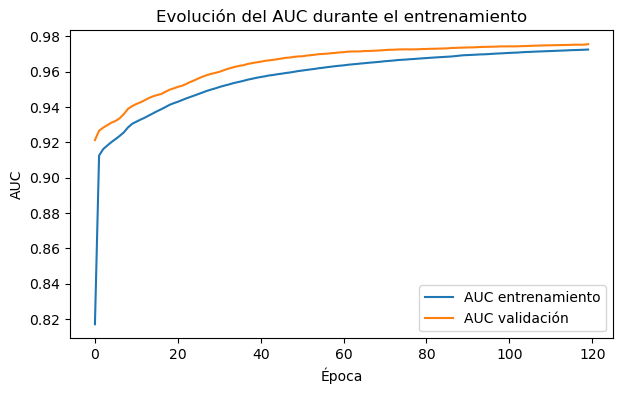

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(historial["auc"], label="AUC entrenamiento")
plt.plot(historial["val_auc"], label="AUC validación")
plt.title("Evolución del AUC durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("AUC")
plt.legend()
plt.show()

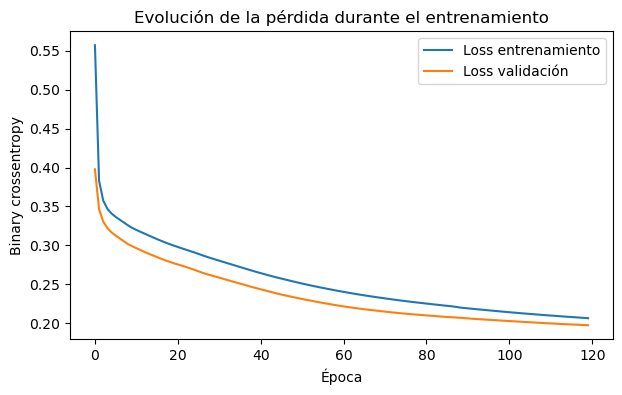

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(historial["loss"], label="Loss entrenamiento")
plt.plot(historial["val_loss"], label="Loss validación")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Binary crossentropy")
plt.legend()
plt.show()

## 11. Evaluación final: ROC y AUC

Se calcula la probabilidad predicha para la clase `1`, se construye la curva ROC y se calcula el AUC final en test.

In [28]:
y_pred_prob_nn = model.predict(X_test_nn).ravel()
y_pred_nn = (y_pred_prob_nn >= 0.5).astype(int)

auc_nn = roc_auc_score(y_test, y_pred_prob_nn)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_nn)

print("AUC red neuronal:", round(auc_nn, 4))
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_nn, digits=4))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_nn))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
AUC red neuronal: 0.9714
Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9305    0.8942    0.9120       794
           1     0.8981    0.9332    0.9153       793

    accuracy                         0.9137      1587
   macro avg     0.9143    0.9137    0.9136      1587
weighted avg     0.9143    0.9137    0.9136      1587

Matriz de confusión:
[[710  84]
 [ 53 740]]


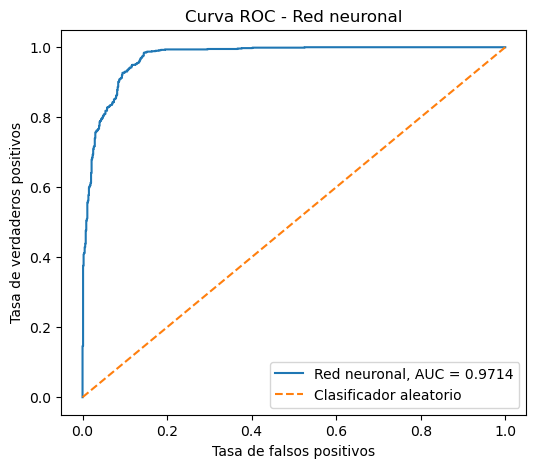

In [29]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Red neuronal, AUC = {auc_nn:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.title("Curva ROC - Red neuronal")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.show()

## 12. Conclusión

El flujo completo permite predecir la renuncia de clientes usando redes neuronales:

1. Se cargaron y revisaron los datos.
2. Se analizó `Subscription Length` según la clase `Churn`.
3. Se estandarizaron las variables regresoras.
4. Se balanceó la clase objetivo con SMOTE.
5. RandomForest identificó las 7 variables más importantes.
6. Con esas variables se entrenó una red neuronal feedforward con una capa oculta.
7. El desempeño final se evaluó con ROC y AUC.

Un AUC superior a 0.90 indica que el modelo distingue correctamente entre clientes que renuncian y clientes que no renuncian en la mayoría de los casos.